#  Análisis exploratorio: Online Retail II

## Análisis exploratorio del dataset

En este apartado se realiza un análisis exploratorio del dataset *Online Retail II*, cuyo objetivo es comprender la estructura de los datos, detectar posibles problemas de calidad y extraer los primeros insights relevantes.

El dataset contiene información transaccional de un e-commerce, incluyendo productos, clientes, fechas de compra, cantidades y precios.

Este análisis inicial es clave para:

- Detectar inconsistencias o errores en los datos  
- Entender el comportamiento general de las variables  
- Definir correctamente la estrategia de modelado posterior  

In [1]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot')
sns.set_palette('husl')

## 1. Carga de datos

Se carga el dataset desde un archivo Excel que contiene múltiples hojas, unificándolas en un único DataFrame. La ruta hay que añadir siempre donde tengas tu archivo de excel para poder ejecutar el notebook sin fallos.

Esto permite trabajar con todo el histórico de transacciones de forma consolidada.

Se obtiene un dataset con más de **1 millón de registros y 8 variables**, lo que indica un volumen de datos suficientemente grande para un análisis robusto.

In [3]:
# Ruta al dataset (ajusta si es necesario)
DATA_PATH = r'C:\Users\alvar\Downloads\online_retail_II.xlsx'

# Si el Excel tiene varias hojas, podemos cargar la primera o especificar por nombre
#df = pd.read_excel(DATA_PATH, sheet_name=1)
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names], ignore_index=True)
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')

Filas: 1,067,371 | Columnas: 8


## 2. Primera inspección
Se realiza una inspección inicial para entender:

- Estructura del dataset (`df.info()`)  
- Tipos de datos  
- Ejemplos de registros (`df.head()`)  

Se identifican variables clave:

- `Invoice`: identificador de transacción  
- `Customer ID`: identificador de cliente  
- `InvoiceDate`: fecha de compra  
- `Quantity` y `Price`: base para calcular ingresos  

También se detecta que:

- Existen valores nulos en `Customer ID`  
- Algunas variables requieren transformación de tipo  

In [4]:
df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [6]:
df.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

## 3. Calidad de datos
Se analizan problemas de calidad:

### 🔹 Valores nulos

- Especialmente en `Customer ID`, lo que impide identificar al cliente  

### 🔹 Duplicados

- Se detectan más de **34.000 registros duplicados**, que deben eliminarse  

In [7]:
# Nulos y duplicados
print("Nulos por columna:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicados exactos:", df.duplicated().sum())

print("\nResumen rápido:")
print("Clientes únicos (raw):", df['Customer ID'].nunique())
print("Facturas únicas (raw):", df['Invoice'].nunique())
print("Periodo (raw):", df['InvoiceDate'].min(), "->", df['InvoiceDate'].max())


Nulos por columna:


Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64


Duplicados exactos: 34335

Resumen rápido:
Clientes únicos (raw): 5942
Facturas únicas (raw): 53628
Periodo (raw): 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


### 🔹 Resumen del dataset

- ~5.900 clientes únicos  
- ~53.000 facturas  
- Periodo temporal: 2009–2011  

**Insight importante:**  
El dataset contiene tanto compras como cancelaciones, lo cual afecta directamente al análisis si no se trata correctamente.

## 4. Estadísticas descriptivas


In [8]:
df.describe(include='all')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,NaN
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN


## 5. Visualizaciones
Se analizan las distribuciones de variables clave:

### Quantity y Price

- Distribuciones fuertemente sesgadas  
- Presencia de valores negativos (devoluciones)  
- Outliers extremos  

**Insight:**  
Los datos no son "limpios", reflejan comportamiento real de negocio (devoluciones, errores, grandes pedidos).

Esto justifica la necesidad de una limpieza rigurosa.


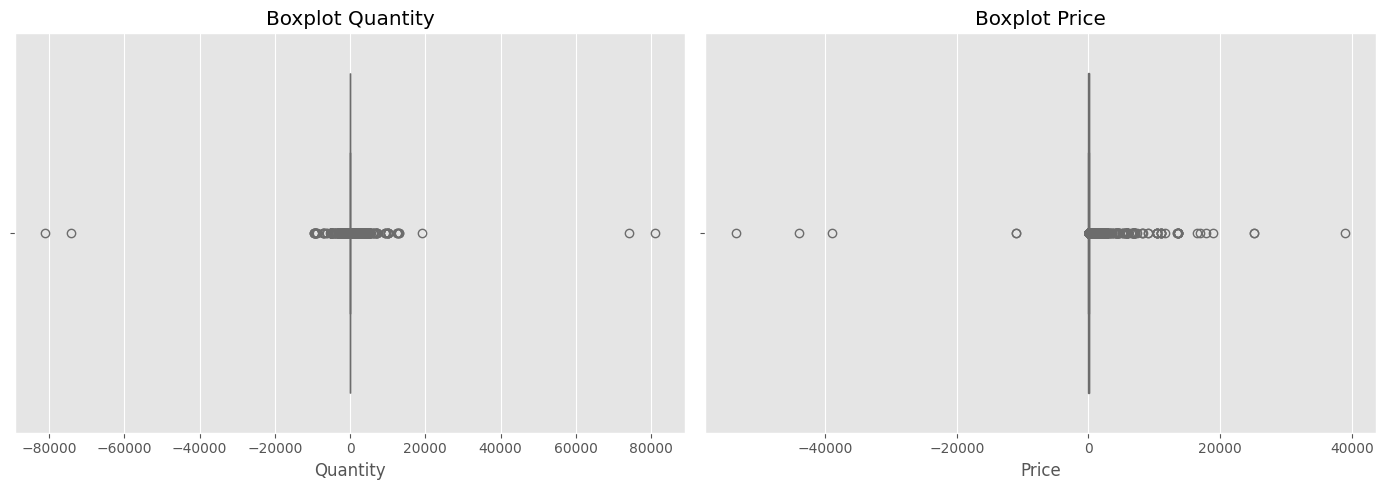

In [9]:
# Distribuciones básicas antes de modelar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['Quantity'], ax=axes[0])
axes[0].set_title('Boxplot Quantity')

sns.boxplot(x=df['Price'], ax=axes[1])
axes[1].set_title('Boxplot Price')

plt.tight_layout()
plt.show()


## 5.1 Limpieza reutilizable
## Limpieza y preparación de datos

En este bloque he definido una función reutilizable para limpiar el dataset, con el objetivo de dejar los datos preparados para el análisis y el modelado.

He decidido encapsular la limpieza en una función porque me permite mantener el código más ordenado y reutilizable, además de separar claramente esta fase del resto del pipeline.

### Qué hago en este paso

- Elimino duplicados para evitar inflar artificialmente métricas como el número de compras o el revenue.
- Convierto tipos de datos, especialmente fechas y el identificador de cliente.
- Elimino registros sin `Customer ID`, ya que no permiten trabajar a nivel cliente.
- Filtro valores negativos en `Quantity` y `Price`, ya que corresponden a devoluciones y no representan comportamiento real de compra.
- Creo la variable `line_total` como producto de cantidad por precio, que será clave para calcular métricas de gasto.

### Por qué lo hago así

Trabajo con un dataset real de e-commerce, donde es habitual encontrar ruido (devoluciones, duplicados, errores). Por eso, esta limpieza es fundamental para asegurar que el modelo aprenda sobre comportamiento real y no sobre inconsistencias.

Este paso transforma los datos “crudos” en una base coherente y lista para análisis.

In [10]:
def clean_retail_data(df):
    """
    Limpieza reutilizable para Online Retail II.

    Qué hace:
    - estandariza nombres de columnas
    - elimina duplicados exactos
    - convierte tipos
    - marca cancelaciones
    - elimina filas sin Customer ID o sin fecha
    - deja solo compras válidas para el modelado principal
    - crea el importe por línea
    """

    df = df.copy()
    df.columns = df.columns.str.strip()

    # Duplicados exactos
    df = df.drop_duplicates()

    # Tipos
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    df['Customer ID'] = pd.to_numeric(df['Customer ID'], errors='coerce')

    # Marcar cancelaciones
    df['is_cancellation'] = df['Invoice'].astype(str).str.startswith('C').astype(int)

    # Filas críticas
    df = df.dropna(subset=['Customer ID', 'InvoiceDate'])

    # Tipo de cliente
    df['Customer ID'] = df['Customer ID'].astype(int)

    # Para el modelo principal nos quedamos con compras reales
    df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

    # Revenue por línea
    df['line_total'] = df['Quantity'] * df['Price']

    return df


In [11]:
df_clean = clean_retail_data(df)

print("Dimensión original:", df.shape)
print("Dimensión limpia:", df_clean.shape)
print("Clientes únicos (clean):", df_clean['Customer ID'].nunique())
print("Facturas únicas (clean):", df_clean['Invoice'].nunique())
print("Periodo (clean):", df_clean['InvoiceDate'].min(), "->", df_clean['InvoiceDate'].max())

df_clean.head()


Dimensión original: (1067371, 8)
Dimensión limpia: (779425, 10)
Clientes únicos (clean): 5878
Facturas únicas (clean): 36969
Periodo (clean): 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation,line_total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,0,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,0,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,0,30.0


In [12]:
# Resumen de negocio tras la limpieza
print("Nº clientes (raw):", df['Customer ID'].nunique())
print("Periodo raw:", df['InvoiceDate'].min(), "-", df['InvoiceDate'].max())
print("Total transacciones (raw):", df['Invoice'].nunique())
print("-" * 50)
print("Nº clientes (clean):", df_clean['Customer ID'].nunique())
print("Periodo clean:", df_clean['InvoiceDate'].min(), "-", df_clean['InvoiceDate'].max())
print("Total transacciones (clean):", df_clean['Invoice'].nunique())


Nº clientes (raw): 5942
Periodo raw: 2009-12-01 07:45:00 - 2011-12-09 12:50:00
Total transacciones (raw): 53628
--------------------------------------------------
Nº clientes (clean): 5878
Periodo clean: 2009-12-01 07:45:00 - 2011-12-09 12:50:00
Total transacciones (clean): 36969


## 6. Preparación del problema supervisado

## Definición del problema de modelado

En este punto planteo el problema como una clasificación binaria: quiero predecir si un cliente va a recomprar o no en los próximos 3 meses.

### Enfoque que he seguido

He optado por un enfoque temporal, separando claramente:

- Un histórico para construir las variables
- Una ventana futura de 3 meses para definir el target

### Por qué es importante

Esto me permite evitar el data leakage, es decir, que el modelo utilice información futura que en un escenario real no estaría disponible.

De esta forma, el modelo aprende únicamente del pasado y predice sobre el futuro, lo que hace que los resultados sean mucho más realistas y defendibles.

### Construcción del target

Marco como 1 a los clientes que aparecen en la ventana futura, y como 0 a los que no vuelven a comprar.

Con esto, convierto un problema de comportamiento en un problema supervisado claro.


In [13]:
# Se reservan los últimos 3 meses del dataset para construir el target
max_date = df_clean['InvoiceDate'].max()
cutoff_date = max_date - pd.DateOffset(months=3)

df_train = df_clean[df_clean['InvoiceDate'] < cutoff_date].copy()
df_future = df_clean[df_clean['InvoiceDate'] >= cutoff_date].copy()

future_customers = df_future['Customer ID'].unique()

print("Fecha máxima del dataset:", max_date)
print("Cutoff (3 últimos meses):", cutoff_date)
print("Periodo train:", df_train['InvoiceDate'].min(), "->", df_train['InvoiceDate'].max())
print("Periodo target:", df_future['InvoiceDate'].min(), "->", df_future['InvoiceDate'].max())
print("Clientes en train:", df_train['Customer ID'].nunique())
print("Clientes que recompran en target:", len(future_customers))


Fecha máxima del dataset: 2011-12-09 12:50:00
Cutoff (3 últimos meses): 2011-09-09 12:50:00
Periodo train: 2009-12-01 07:45:00 -> 2011-09-09 12:41:00
Periodo target: 2011-09-09 13:01:00 -> 2011-12-09 12:50:00
Clientes en train: 5279
Clientes que recompran en target: 2893


## 6.1 Construcción de variables a nivel cliente

## Construcción de variables a nivel cliente

En este bloque transformo los datos transaccionales en un dataset a nivel cliente, que es la unidad sobre la que quiero hacer la predicción.

### Por qué agrego a nivel cliente

El objetivo es predecir si un cliente recompra, por lo que necesito resumir todo su comportamiento histórico en un conjunto de variables representativas.

### Variables principales (RFM)

He construido las variables clásicas de marketing:

- Recency: días desde la última compra
- Frequency: número de compras
- Monetary: gasto total

Estas variables son muy utilizadas porque capturan muy bien la relación del cliente con el negocio.

### Variables adicionales

Además, he añadido variables que complementan el comportamiento:

- Ticket medio
- Número de productos distintos
- Número de compras
- Importe de la última compra
- Métricas de intensidad de compra

También he creado variables derivadas, como ratios o relaciones entre variables, para capturar patrones más complejos.

### Qué busco con esto

No solo quiero saber cuánto compra un cliente, sino cómo compra: si es reciente, frecuente, variado, intensivo, etc.

Este bloque es clave porque aquí es donde realmente construyo la información que el modelo va a utilizar.


In [14]:
# Variables RFM clásicas a nivel cliente
snapshot_date = df_train['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_train.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'line_total': 'sum'
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']
rfm.head()


,Customer ID,Recency,Frequency,Monetary
0,12346,235,12,77556.46
1,12347,39,6,3402.39
2,12348,158,4,1709.40
3,12349,317,3,2671.14
4,12350,219,1,334.40


In [15]:
# ============================================================
# Feature engineering a nivel cliente
# ============================================================

# Ticket medio
rfm['avg_ticket'] = rfm['Monetary'] / rfm['Frequency']

# Número de productos distintos comprados
products = df_train.groupby('Customer ID')['StockCode'].nunique().reset_index()
products.columns = ['Customer ID', 'num_products']
rfm = rfm.merge(products, on='Customer ID', how='left')

# Número de descripciones distintas
descriptions = df_train.groupby('Customer ID')['Description'].nunique().reset_index()
descriptions.columns = ['Customer ID', 'num_descriptions']
rfm = rfm.merge(descriptions, on='Customer ID', how='left')

# Número de países distintos
countries = df_train.groupby('Customer ID')['Country'].nunique().reset_index()
countries.columns = ['Customer ID', 'num_countries']
rfm = rfm.merge(countries, on='Customer ID', how='left')

# Cantidad total de artículos comprados
qty = df_train.groupby('Customer ID')['Quantity'].sum().reset_index()
qty.columns = ['Customer ID', 'total_quantity']
rfm = rfm.merge(qty, on='Customer ID', how='left')

# Dataset a nivel factura para crear variables de ticket
invoice_level = (
    df_train.groupby(['Customer ID', 'Invoice'], as_index=False)
    .agg(
        invoice_date=('InvoiceDate', 'min'),
        invoice_amount=('line_total', 'sum'),
        invoice_items=('Quantity', 'sum'),
        invoice_products=('StockCode', 'nunique')
    )
)

# Importe de la última factura
last_invoice = (
    invoice_level.sort_values(['Customer ID', 'invoice_date'])
    .groupby('Customer ID')
    .tail(1)[['Customer ID', 'invoice_amount']]
    .rename(columns={'invoice_amount': 'last_invoice_amount'})
)
rfm = rfm.merge(last_invoice, on='Customer ID', how='left')

# Importe medio por factura
mean_invoice_amount = invoice_level.groupby('Customer ID')['invoice_amount'].mean().reset_index()
mean_invoice_amount.columns = ['Customer ID', 'mean_invoice_amount']
rfm = rfm.merge(mean_invoice_amount, on='Customer ID', how='left')

# Relación entre la última factura y el ticket medio
rfm['ratio_last_invoice_mean'] = rfm['last_invoice_amount'] / rfm['mean_invoice_amount']

# Variables temporales simples
rfm['freq_per_recency'] = rfm['Frequency'] / (rfm['Recency'] + 1)
rfm['monetary_per_recency'] = rfm['Monetary'] / (rfm['Recency'] + 1)
rfm['is_recent_customer'] = (rfm['Recency'] <= 30).astype(int)

# Target: 1 si el cliente reaparece en los últimos 3 meses
rfm['target'] = rfm['Customer ID'].isin(future_customers).astype(int)

# Limpieza final
rfm = rfm.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Shape final del dataset de modelado:", rfm.shape)
display(rfm.head())


Shape final del dataset de modelado: (5279, 16)


,Customer ID,Recency,Frequency,Monetary,avg_ticket,num_products,num_descriptions,num_countries,total_quantity,last_invoice_amount,mean_invoice_amount,ratio_last_invoice_mean,freq_per_recency,monetary_per_recency,is_recent_customer,target
0,12346,235,12,77556.46,6463.038333,27,26,1,74285,77183.60,6463.038333,11.942309,0.050847,328.629068,0,0
1,12347,39,6,3402.39,567.065000,107,107,1,2099,584.91,567.065000,1.031469,0.150000,85.059750,0,1
2,12348,158,4,1709.40,427.350000,25,28,1,2497,367.00,427.350000,0.858781,0.025157,10.750943,0,1
3,12349,317,3,2671.14,890.380000,90,94,1,993,1402.62,890.380000,1.575305,0.009434,8.399811,0,1
4,12350,219,1,334.40,334.400000,17,17,1,197,334.40,334.400000,1.000000,0.004545,1.520000,0,0


## 7. Modelado

## Modelado y comparación de algoritmos

En este bloque entreno varios modelos de clasificación para comparar su rendimiento.

### Separación train/test

He dividido los datos en entrenamiento y test usando `stratify`, para mantener la proporción de clientes que recompran y no recompran en ambos conjuntos.

### Modelos utilizados

He probado distintos modelos:

- Regresión logística como baseline
- Random Forest como modelo robusto y fácil de interpretar
- XGBoost, LightGBM y CatBoost como modelos de boosting más avanzados

### Por qué esta elección

Quería comparar modelos simples y complejos para ver hasta qué punto el problema se puede capturar con distintas aproximaciones.

Los modelos de boosting son especialmente potentes en datos tabulares, por lo que era importante incluirlos.

### Métrica utilizada

He utilizado ROC-AUC porque me interesa medir la capacidad del modelo para diferenciar entre clientes que recompran y los que no, independientemente del umbral.

### Ensemble

Además, he probado una combinación de modelos mediante un ensemble ponderado, para aprovechar las fortalezas de cada uno.

### Conclusión de este bloque

Este paso me permite identificar qué modelo funciona mejor y entender el comportamiento general del problema.


In [16]:
from sklearn.model_selection import train_test_split

X = rfm.drop(['Customer ID', 'target'], axis=1)
y = rfm['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Tasa target train:", round(y_train.mean(), 4))
print("Tasa target test:", round(y_test.mean(), 4))


X_train: (3695, 14)
X_test: (1584, 14)
Tasa target train: 0.4346
Tasa target test: 0.4343


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("AUC Logistic:", roc_auc_score(y_test, y_pred_lr))


AUC Logistic: 0.7915314835963455


In [18]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=1200,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_rf)

print("AUC Random Forest:", auc_rf)


AUC Random Forest: 0.790160727263289


In [19]:

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    reg_lambda=1.0,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)

print("AUC XGBoost:", auc_xgb)


AUC XGBoost: 0.7926572882059799


In [20]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbosity=-1
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict_proba(X_test)[:, 1]
auc_lgbm = roc_auc_score(y_test, y_pred_lgbm)

print("AUC LightGBM:", auc_lgbm)

AUC LightGBM: 0.7828478638911961


In [21]:

from catboost import CatBoostClassifier

cat = CatBoostClassifier(
    iterations=700,
    depth=5,
    learning_rate=0.03,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=0,
    random_seed=42
)

cat.fit(X_train, y_train)
y_pred_cat = cat.predict_proba(X_test)[:, 1]
auc_cat = roc_auc_score(y_test, y_pred_cat)

print("AUC CatBoost:", auc_cat)


AUC CatBoost: 0.7945666138911961


In [22]:
# Ensemble ponderado de probabilidades
# Damos más peso a los modelos con mejor desempeño individual.
y_pred_ens = (
    0.20 * y_pred_rf +
    0.25 * y_pred_xgb +
    0.20 * y_pred_lgbm +
    0.35 * y_pred_cat
)
auc_ens = roc_auc_score(y_test, y_pred_ens)

results = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM', 'CatBoost', 'Ensemble ponderado'],
    'AUC': [roc_auc_score(y_test, y_pred_lr), auc_rf, auc_xgb, auc_lgbm, auc_cat, auc_ens]
}).sort_values('AUC', ascending=False)

display(results)
print("Mejor AUC base:", results.iloc[0]['AUC'])

,Modelo,AUC
4,CatBoost,0.794567
5,Ensemble ponderado,0.793958
2,XGBoost,0.792657
0,Logistic Regression,0.791531
1,Random Forest,0.790161
3,LightGBM,0.782848


Mejor AUC base: 0.7945666138911961


## 7.1 Optimización de hiperparámetros:

## Optimización del modelo con Optuna y LightGBM

En este bloque optimizo el modelo LightGBM utilizando Optuna.

### Por qué LightGBM

He elegido LightGBM porque es un modelo muy eficiente y potente para datos tabulares, capaz de capturar relaciones no lineales y patrones complejos.

### Por qué Optuna

En lugar de hacer una búsqueda manual, utilizo Optuna para optimizar automáticamente los hiperparámetros.

Optuna explora el espacio de parámetros de forma más eficiente que un grid search tradicional, permitiendo encontrar buenas configuraciones en menos tiempo.

### Validación

Uso validación cruzada con `StratifiedKFold` para asegurar que el rendimiento es estable y no depende de una única partición.

### Resultado

Este proceso me permite obtener el mejor modelo del proyecto, con un AUC cercano a 0.80.

### Valor del bloque

Este paso aporta un nivel más avanzado al proyecto, ya que no solo entreno modelos, sino que los optimizo de forma rigurosa.

In [23]:

from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier(
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [400, 800],
    'max_depth': [10, 16, None],
    'min_samples_split': [2, 4, 8],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf_grid = grid_search.best_estimator_
y_pred_rf_grid = best_rf_grid.predict_proba(X_test)[:, 1]
auc_rf_grid = roc_auc_score(y_test, y_pred_rf_grid)

print("Mejores parámetros RF (GridSearch):")
print(grid_search.best_params_)
print("AUC Random Forest + GridSearch:", auc_rf_grid)


Fitting 3 folds for each of 108 candidates, totalling 324 fits


c:\Users\alvar\Downloads\datasetsClase\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejores parámetros RF (GridSearch):
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 400}
AUC Random Forest + GridSearch: 0.7964110517026579


## 7.2 Optimización de hiperparámetros: 

Se realiza optimización automática avanzada:

- Búsqueda eficiente de hiperparámetros  
- Validación cruzada  

**Resultado:**  

- Mejor modelo del proyecto → LightGBM optimizado  
- AUC ≈ **0.80**

**Insight:**  
La optimización automática mejora el rendimiento del modelo.


In [24]:

!pip install optuna -q

import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
c:\Users\alvar\Downloads\datasetsClase\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 900),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 5.0),
        'random_state': 42,
        'verbosity': -1
    }

    model = LGBMClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=cv,
        n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective_lgbm, n_trials=20, show_progress_bar=False)

best_params_optuna = study.best_params
best_lgbm_optuna = LGBMClassifier(**best_params_optuna, random_state=42, verbosity=-1)

best_lgbm_optuna.fit(X_train, y_train)
y_pred_lgbm_optuna = best_lgbm_optuna.predict_proba(X_test)[:, 1]
auc_lgbm_optuna = roc_auc_score(y_test, y_pred_lgbm_optuna)

print("Mejores parámetros LGBM (Optuna):")
print(best_params_optuna)
print("Mejor AUC CV (Optuna):", study.best_value)
print("AUC LightGBM + Optuna en test:", auc_lgbm_optuna)

[I 2026-03-25 23:04:12,591] A new study created in memory with name: no-name-872f2309-cc99-4724-a0a2-0923918d9059
[I 2026-03-25 23:04:16,308] Trial 0 finished with value: 0.7761556033771383 and parameters: {'n_estimators': 333, 'learning_rate': 0.021693909142691793, 'num_leaves': 53, 'max_depth': 8, 'min_child_samples': 27, 'subsample': 0.7942663983418382, 'colsample_bytree': 0.9789797640832767, 'reg_lambda': 1.680759296232529}. Best is trial 0 with value: 0.7761556033771383.
[I 2026-03-25 23:04:18,413] Trial 1 finished with value: 0.7786905861709452 and parameters: {'n_estimators': 525, 'learning_rate': 0.025674731810447295, 'num_leaves': 15, 'max_depth': 6, 'min_child_samples': 23, 'subsample': 0.9283674705582567, 'colsample_bytree': 0.9834200345865146, 'reg_lambda': 3.8351031701781406}. Best is trial 1 with value: 0.7786905861709452.
[I 2026-03-25 23:04:20,698] Trial 2 finished with value: 0.7739142969190764 and parameters: {'n_estimators': 783, 'learning_rate': 0.03450314385829416,

Mejores parámetros LGBM (Optuna):
{'n_estimators': 356, 'learning_rate': 0.012993922539651297, 'num_leaves': 31, 'max_depth': 3, 'min_child_samples': 35, 'subsample': 0.7085778091755379, 'colsample_bytree': 0.7778303405256466, 'reg_lambda': 4.236217992563103}
Mejor AUC CV (Optuna): 0.7917877365215421
AUC LightGBM + Optuna en test: 0.8028633396490865


In [26]:
# Comparativa ampliada con modelos optimizados
results_opt = pd.DataFrame({
    'Modelo': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost',
        'Ensemble ponderado',
        'Random Forest + GridSearch',
        'LightGBM + Optuna'
    ],
    'AUC': [
        roc_auc_score(y_test, y_pred_lr),
        auc_rf,
        auc_xgb,
        auc_lgbm,
        auc_cat,
        auc_ens,
        auc_rf_grid,
        auc_lgbm_optuna
    ]
}).sort_values('AUC', ascending=False)

display(results_opt)
print("Mejor modelo tras optimización:", results_opt.iloc[0]['Modelo'])
print("Mejor AUC tras optimización:", results_opt.iloc[0]['AUC'])

pred_map = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb,
    'LightGBM': y_pred_lgbm,
    'CatBoost': y_pred_cat,
    'Ensemble ponderado': y_pred_ens,
    'Random Forest + GridSearch': y_pred_rf_grid,
    'LightGBM + Optuna': y_pred_lgbm_optuna
}

best_model_name = results_opt.iloc[0]['Modelo']
best_pred = pred_map[best_model_name]
print("Se utilizará este modelo para el análisis post-modelado:", best_model_name)

,Modelo,AUC
7,LightGBM + Optuna,0.802863
6,Random Forest + GridSearch,0.796411
4,CatBoost,0.794567
5,Ensemble ponderado,0.793958
2,XGBoost,0.792657
0,Logistic Regression,0.791531
1,Random Forest,0.790161
3,LightGBM,0.782848


Mejor modelo tras optimización: LightGBM + Optuna
Mejor AUC tras optimización: 0.8028633396490865
Se utilizará este modelo para el análisis post-modelado: LightGBM + Optuna


## 8. Modelo: explicabilidad
Se analiza la importancia de variables:

### Variables más relevantes:

- Monetary  
- Recency  
- Frequency  
- Variables derivadas  

**Insight clave:**  
Clientes recientes, frecuentes y con alto gasto tienen mayor probabilidad de recompra.

monetary_per_recency       0.138391
freq_per_recency           0.135664
Recency                    0.125484
Monetary                   0.092936
total_quantity             0.081358
num_descriptions           0.065894
num_products               0.065649
last_invoice_amount        0.061170
mean_invoice_amount        0.060220
avg_ticket                 0.060220
Frequency                  0.054921
ratio_last_invoice_mean    0.051016
is_recent_customer         0.007075
num_countries              0.000001
dtype: float64

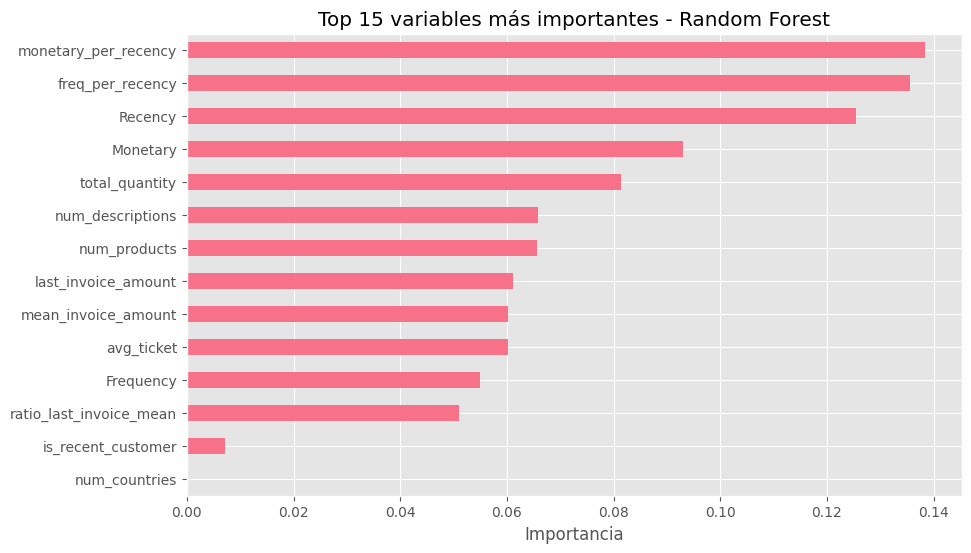

In [27]:

# Importancia de variables del Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

display(importances.head(15))

plt.figure(figsize=(10, 6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.show()


##  Curvas ROC

- Buen equilibrio entre verdaderos positivos y falsos positivos  
- El modelo optimizado mejora ligeramente  

**Interpretación:**  
El modelo tiene buena capacidad de discriminación.

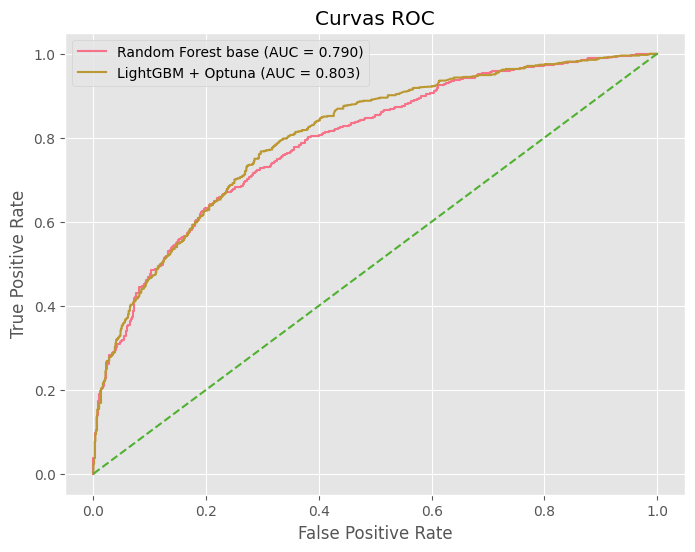

In [28]:
from sklearn.metrics import roc_curve

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf)
fpr_best, tpr_best, _ = roc_curve(y_test, best_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest base (AUC = {auc_rf:.3f})')
plt.plot(fpr_best, tpr_best, label=f'{best_model_name} (AUC = {results_opt.iloc[0]["AUC"]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("Curvas ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## 8.1 Evaluación adicional: Precision-Recall y umbral de decisión

Se analiza:

- Relación Precision vs Recall  
- F1-score según umbral  

**Insight:**  
Existe un umbral óptimo (~0.3–0.4).

**Aplicación:**  
Permite definir campañas más eficientes.

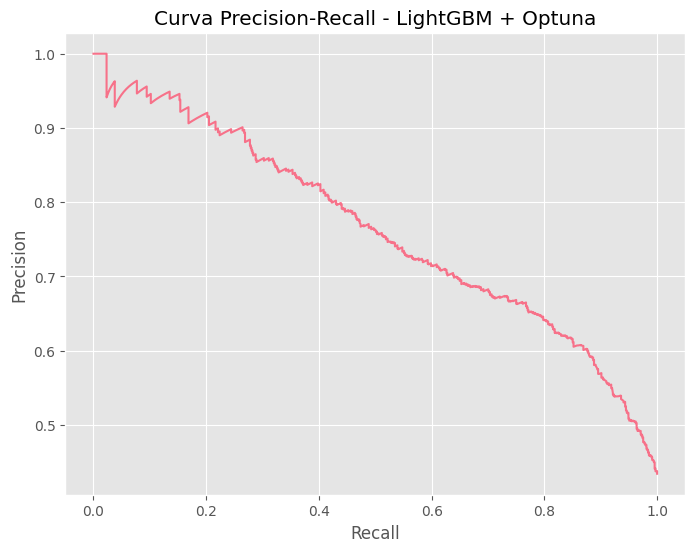

In [29]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_test, best_pred)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.title(f"Curva Precision-Recall - {best_model_name}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Threshold óptimo según F1: 0.34
F1 asociado: 0.7139


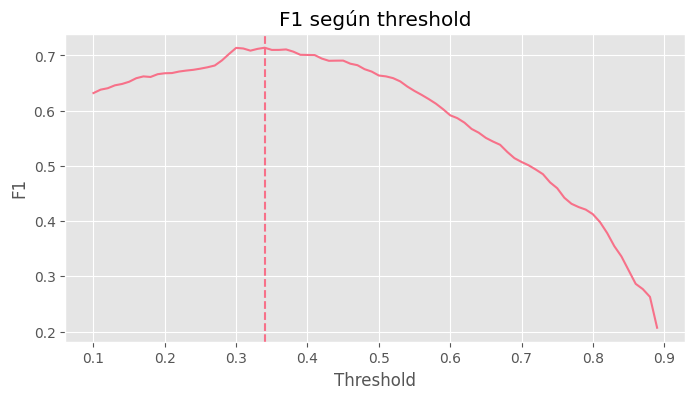

In [30]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.10, 0.90, 0.01)
f1_scores = [f1_score(y_test, (best_pred >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[int(np.argmax(f1_scores))]
best_f1 = max(f1_scores)

print("Threshold óptimo según F1:", round(float(best_threshold), 2))
print("F1 asociado:", round(float(best_f1), 4))

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, linestyle='--')
plt.title("F1 según threshold")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.show()

## 8.1 Explicabilidad con DALEX

## Explicabilidad del modelo con DALEX

En este bloque utilizo la librería DALEX para interpretar el modelo.

### Por qué añado explicabilidad

No solo me interesa que el modelo prediga bien, sino también entender por qué toma determinadas decisiones.

Esto es especialmente importante en negocio, donde las decisiones deben ser justificables.

### Qué hago

- Construyo un explainer que conecta el modelo con los datos
- Analizo la importancia global de variables
- Analizo el comportamiento del modelo para un cliente concreto

### Qué aporta

- A nivel global, entiendo qué variables influyen más
- A nivel individual, veo cómo cada variable afecta a una predicción concreta

### Conclusión

Este bloque me permite pasar de un modelo “caja negra” a un modelo interpretable, lo que aumenta su valor en un entorno real.


In [31]:
import dalex as dx


In [32]:

# Elegimos como modelo a explicar el Random Forest base
explainer_rf = dx.Explainer(
    rf,
    X_train,
    y_train,
    label='Random Forest'
)

# Importancia de variables con DALEX
vi_rf = explainer_rf.model_parts()
vi_rf.result.head()


Preparation of a new explainer is initiated

  -> data              : 3695 rows 14 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 3695 values
  -> model_class       : sklearn.ensemble._forest.RandomForestClassifier (default)
  -> label             : Random Forest
  -> predict function  : <function yhat_proba_default at 0x000001EBB27AA8D0> will be used (default)
  -> predict function  : Accepts pandas.DataFrame and numpy.ndarray.
  -> predicted values  : min = 0.00284, mean = 0.449, max = 0.999
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.657, mean = -0.0148, max = 0.643
  -> model_info        : package sklearn

A new explainer has been created!


,variable,dropout_loss,label
0,_full_model_,0.002483,Random Forest
1,num_countries,0.002483,Random Forest
2,is_recent_customer,0.003274,Random Forest
3,Frequency,0.010619,Random Forest
4,ratio_last_invoice_mean,0.011417,Random Forest


In [33]:

# Visualización de importancia de variables
vi_rf.plot()


In [34]:

# Explicación local de un cliente concreto del test
cliente_idx = 0
obs = X_test.iloc[[cliente_idx]]

bd_rf = explainer_rf.predict_parts(obs, type='break_down')
bd_rf.result.head()


,variable_name,variable_value,variable,cumulative,contribution,sign,position,label
0,intercept,,intercept,0.449403,4.494029e-01,1.0,15,Random Forest
1,mean_invoice_amount,211.5,mean_invoice_amount = 211.5,0.467727,1.832365e-02,1.0,14,Random Forest
2,avg_ticket,211.5,avg_ticket = 211.5,0.482562,1.483512e-02,1.0,13,Random Forest
3,last_invoice_amount,211.5,last_invoice_amount = 211.5,0.485878,3.316097e-03,1.0,12,Random Forest
4,num_countries,1.0,num_countries = 1.0,0.485878,-9.858871e-08,-1.0,11,Random Forest


In [35]:

bd_rf.plot()


## 9. EDA post-modelado orientado a negocio

## Traducción del modelo a negocio

En este bloque llevo el modelo a un contexto de negocio.

### Qué hago

A partir de las probabilidades predichas, segmento a los clientes en tres grupos:

- Baja probabilidad de recompra
- Probabilidad media
- Alta probabilidad

### Por qué segmentar

Porque en negocio no se trabaja con probabilidades directamente, sino con decisiones.

Esta segmentación permite definir acciones concretas para cada tipo de cliente.

### Qué analizo

- Número de clientes por segmento
- Tasa real de recompra
- Revenue medio por segmento

### Qué busco

Validar que el modelo tiene sentido desde el punto de vista económico y que permite diferenciar claramente tipos de cliente.

### Valor del bloque

Aquí es donde el modelo deja de ser técnico y se convierte en una herramienta útil para tomar decisiones.

In [36]:
df_post = X_test.copy()
df_post['target_real'] = y_test.values
df_post['proba'] = best_pred

df_post['segment'] = pd.cut(
    df_post['proba'],
    bins=[0, 0.4, 0.7, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

display(df_post.head())

,Recency,Frequency,Monetary,avg_ticket,num_products,num_descriptions,num_countries,total_quantity,last_invoice_amount,mean_invoice_amount,ratio_last_invoice_mean,freq_per_recency,monetary_per_recency,is_recent_customer,target_real,proba,segment
2977,174,1,211.50,211.500000,5,5,1,66,211.50,211.500000,1.000000,0.005714,1.208571,0,0,0.257654,Low
1190,212,2,631.17,315.585000,38,38,1,301,330.79,315.585000,1.048180,0.009390,2.963239,0,0,0.297453,Low
4050,57,8,1201.12,150.140000,94,94,1,382,127.88,150.140000,0.851738,0.137931,20.708966,0,1,0.678307,Medium
1840,421,3,1220.90,406.966667,29,29,1,446,34.90,406.966667,0.085756,0.007109,2.893128,0,0,0.229586,Low
4555,509,1,1047.00,1047.000000,6,6,1,200,1047.00,1047.000000,1.000000,0.001961,2.052941,0,0,0.109135,Low


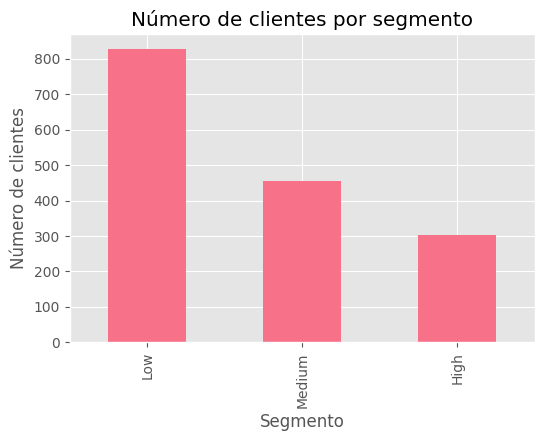

In [37]:
segment_counts = df_post['segment'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
segment_counts.plot(kind='bar')
plt.title("Número de clientes por segmento")
plt.xlabel("Segmento")
plt.ylabel("Número de clientes")
plt.show()

C:\Users\alvar\AppData\Local\Temp\ipykernel_25304\4035356772.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  repurchase_rate = df_post.groupby('segment')['target_real'].mean()


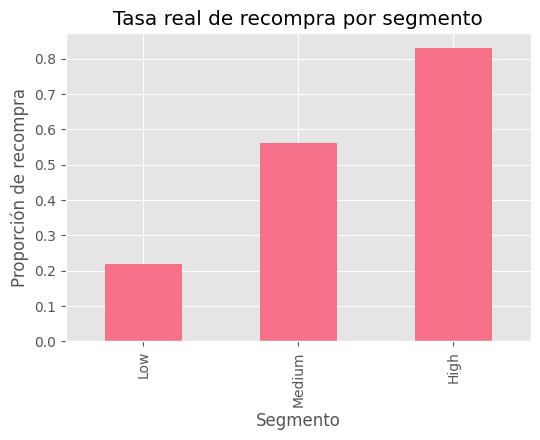

In [38]:
repurchase_rate = df_post.groupby('segment')['target_real'].mean()

plt.figure(figsize=(6, 4))
repurchase_rate.plot(kind='bar')
plt.title("Tasa real de recompra por segmento")
plt.xlabel("Segmento")
plt.ylabel("Proporción de recompra")
plt.show()

C:\Users\alvar\AppData\Local\Temp\ipykernel_25304\848586204.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_revenue_segment = df_post.groupby('segment')['Monetary'].mean()


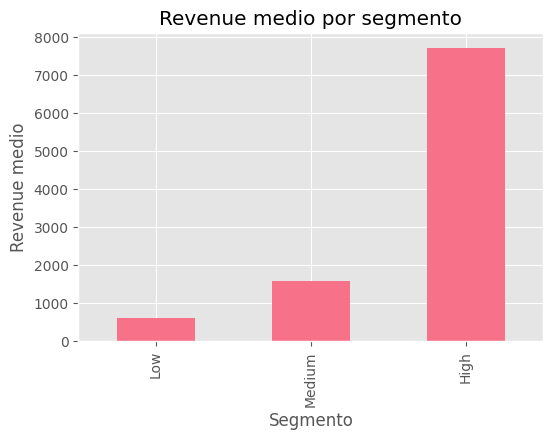

In [39]:
avg_revenue_segment = df_post.groupby('segment')['Monetary'].mean()

plt.figure(figsize=(6, 4))
avg_revenue_segment.plot(kind='bar')
plt.title("Revenue medio por segmento")
plt.xlabel("Segmento")
plt.ylabel("Revenue medio")
plt.show()

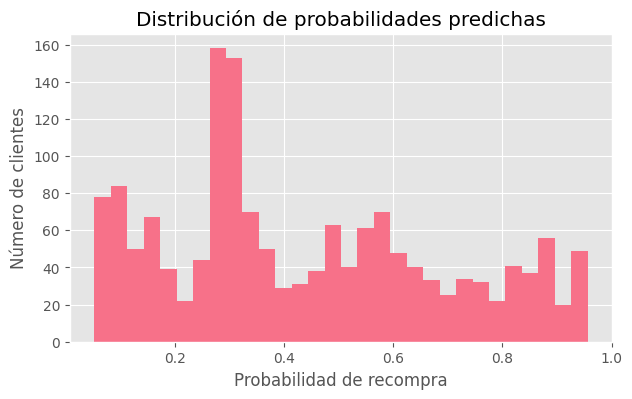

In [40]:
plt.figure(figsize=(7, 4))
plt.hist(df_post['proba'], bins=30)
plt.title("Distribución de probabilidades predichas")
plt.xlabel("Probabilidad de recompra")
plt.ylabel("Número de clientes")
plt.show()

,year,line_total,prev_year,growth_%
0,2009,683504.010,NaN,NaN
1,2010,8374496.094,683504.010,1125.229987
2,2011,8316804.164,8374496.094,-0.688900


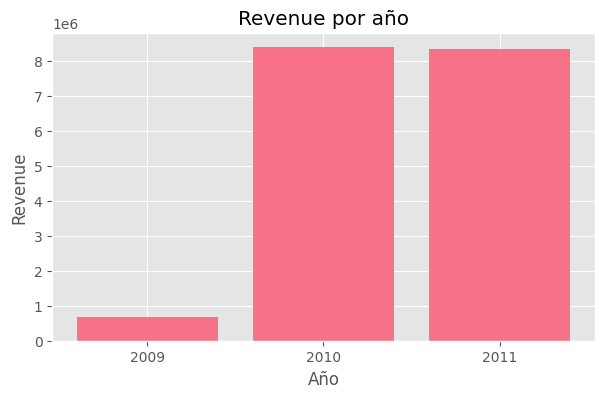

In [41]:
df_clean['year'] = df_clean['InvoiceDate'].dt.year

revenue_year = df_clean.groupby('year')['line_total'].sum().reset_index()
revenue_year['prev_year'] = revenue_year['line_total'].shift(1)
revenue_year['growth_%'] = (
    (revenue_year['line_total'] - revenue_year['prev_year']) / revenue_year['prev_year']
) * 100

display(revenue_year)

plt.figure(figsize=(7, 4))
plt.bar(revenue_year['year'].astype(str), revenue_year['line_total'])
plt.title("Revenue por año")
plt.xlabel("Año")
plt.ylabel("Revenue")
plt.show()

In [42]:
# ============================================
# 9.1 Calidad de datos avanzada
# ============================================

import pandas as pd
import numpy as np

print("=== Duplicados ===")

dup_full = df.duplicated().sum()
print(f"Filas duplicadas (registro entero): {dup_full:,} ({100*dup_full/len(df):.2f}%)")

key_cols = ['Invoice', 'StockCode', 'Description']
subset_key_cols = [c for c in key_cols if c in df.columns]
if subset_key_cols:
    dup_key = df.duplicated(subset=subset_key_cols).sum()
    print(f"Filas duplicadas por {subset_key_cols}: {dup_key:,} ({100*dup_key/len(df):.2f}%)")

print("\n=== Valores negativos ===")
for col in ['Quantity', 'Price']:
    if col in df.columns:
        n_neg = int((df[col] < 0).sum())
        print(f"{col}: {n_neg:,} valores negativos ({100*n_neg/len(df):.2f}%)")

numeric_cols = df.select_dtypes(include='number').columns
negatives = {c: int((df[c] < 0).sum()) for c in numeric_cols}
negatives = {k: v for k, v in negatives.items() if v > 0}

if negatives:
    display(
        pd.Series(negatives, name='negativos')
        .sort_values(ascending=False)
        .to_frame()
    )
else:
    print("No hay negativos en columnas numéricas.")

# Muestra rápida de filas con algún negativo
if negatives:
    cols_neg = list(negatives.keys())
    mask_neg = (df[cols_neg] < 0).any(axis=1)
    print(f"\nMuestra de filas con al menos un negativo ({mask_neg.sum():,} filas):")
    display(df.loc[mask_neg, ['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID', 'InvoiceDate']].head(10))

=== Duplicados ===
Filas duplicadas (registro entero): 34,335 (3.22%)
Filas duplicadas por ['Invoice', 'StockCode', 'Description']: 45,945 (4.30%)

=== Valores negativos ===
Quantity: 22,950 valores negativos (2.15%)
Price: 5 valores negativos (0.00%)


,negativos
Quantity,22950
Price,5



Muestra de filas con al menos un negativo (22,955 filas):


,Invoice,StockCode,Description,Quantity,Price,Customer ID,InvoiceDate
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95,16321.0,2009-12-01 10:33:00
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65,16321.0,2009-12-01 10:33:00
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25,16321.0,2009-12-01 10:33:00
181,C489449,21896,POTTING SHED TWINE,-6,2.10,16321.0,2009-12-01 10:33:00
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95,16321.0,2009-12-01 10:33:00
183,C489449,21871,SAVE THE PLANET MUG,-12,1.25,16321.0,2009-12-01 10:33:00
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,1.25,16321.0,2009-12-01 10:33:00
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,0.85,16321.0,2009-12-01 10:33:00
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2.95,16321.0,2009-12-01 10:33:00
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,4.25,17592.0,2009-12-01 10:44:00


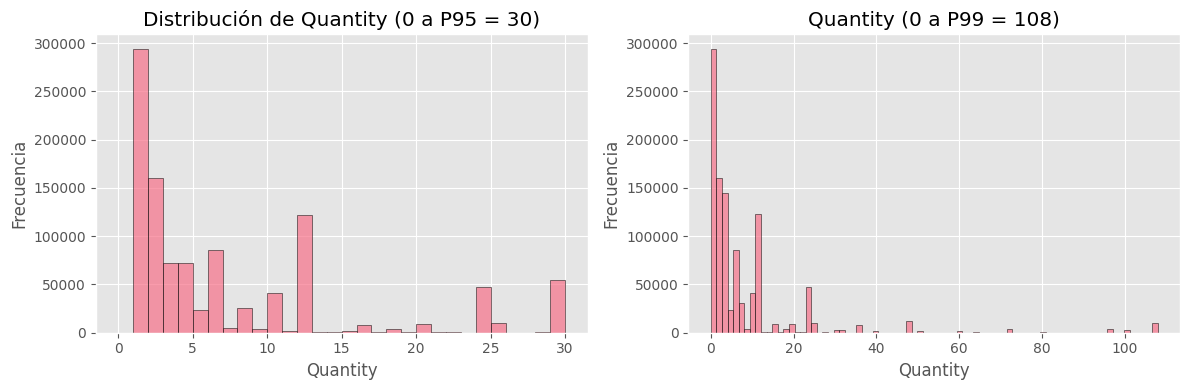

In [43]:
# ============================================
# 9.2 Distribución de Quantity (P95 / P99)
# ============================================

import matplotlib.pyplot as plt

qty_col = 'Quantity'

if qty_col in df.columns:
    qty_pos = df.loc[df[qty_col] > 0, qty_col].dropna()

    q95 = qty_pos.quantile(0.95)
    q99 = qty_pos.quantile(0.99)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    data_p95 = qty_pos.clip(upper=q95)
    bins_p95 = min(60, max(20, int(data_p95.max())))
    axes[0].hist(data_p95, bins=bins_p95, range=(0, q95), edgecolor='black', alpha=0.7)
    axes[0].set_title(f"Distribución de Quantity (0 a P95 = {q95:.0f})")
    axes[0].set_xlabel("Quantity")
    axes[0].set_ylabel("Frecuencia")

    data_p99 = qty_pos.clip(upper=q99)
    bins_p99 = min(80, max(20, int(data_p99.max())))
    axes[1].hist(data_p99, bins=bins_p99, range=(0, q99), edgecolor='black', alpha=0.7)
    axes[1].set_title(f"Quantity (0 a P99 = {q99:.0f})")
    axes[1].set_xlabel("Quantity")
    axes[1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()
else:
    print("No existe la columna 'Quantity'.")

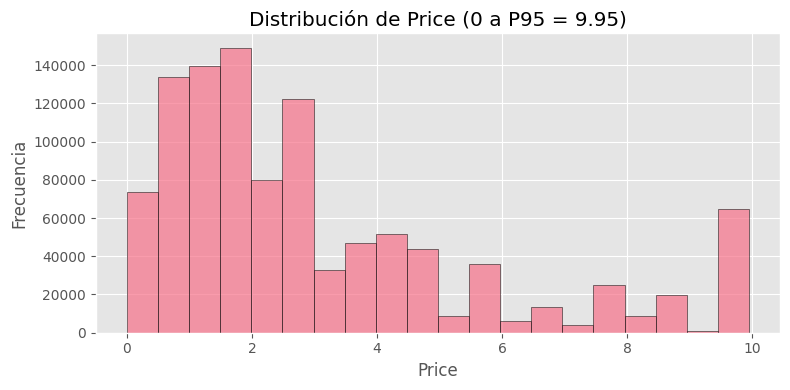

In [44]:
# ============================================
# 9.3 Distribución de Price (P95)
# ============================================

price_col = 'Price'

if price_col in df.columns:
    price_pos = df.loc[df[price_col] > 0, price_col].dropna()
    q95_price = price_pos.quantile(0.95)

    data_price = price_pos.clip(upper=q95_price)
    bins_price = min(60, max(20, int(data_price.max() * 2)))

    plt.figure(figsize=(8, 4))
    plt.hist(data_price, bins=bins_price, range=(0, q95_price), edgecolor='black', alpha=0.7)
    plt.title(f"Distribución de Price (0 a P95 = {q95_price:.2f})")
    plt.xlabel("Price")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()
else:
    print("No existe la columna 'Price'.")

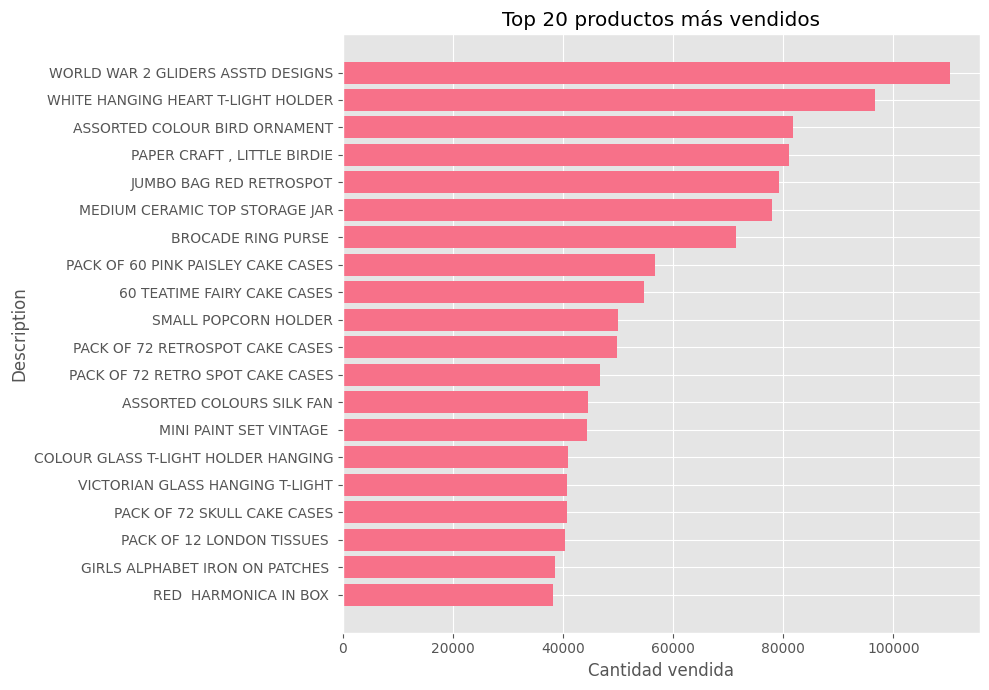

,Description,Quantity
5305,WORLD WAR 2 GLIDERS ASSTD DESIGNS,110249
5184,WHITE HANGING HEART T-LIGHT HOLDER,96688
307,ASSORTED COLOUR BIRD ORNAMENT,81817
3205,"PAPER CRAFT , LITTLE BIRDIE",80995
2455,JUMBO BAG RED RETROSPOT,79285
2765,MEDIUM CERAMIC TOP STORAGE JAR,78033
776,BROCADE RING PURSE,71440
3141,PACK OF 60 PINK PAISLEY CAKE CASES,56794
161,60 TEATIME FAIRY CAKE CASES,54716
4634,SMALL POPCORN HOLDER,49984


In [45]:
# ============================================
# 9.4 Top 20 productos más vendidos
# ============================================

if all(c in df.columns for c in ['Description', 'Quantity']):
    top_products = (
        df.loc[(df['Quantity'] > 0) & (df['Description'].notna())]
        .groupby('Description', as_index=False)['Quantity']
        .sum()
        .sort_values('Quantity', ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 7))
    plt.barh(top_products['Description'][::-1], top_products['Quantity'][::-1])
    plt.title("Top 20 productos más vendidos")
    plt.xlabel("Cantidad vendida")
    plt.ylabel("Description")
    plt.tight_layout()
    plt.show()

    display(top_products)
else:
    print("Faltan columnas necesarias: 'Description' y/o 'Quantity'.")

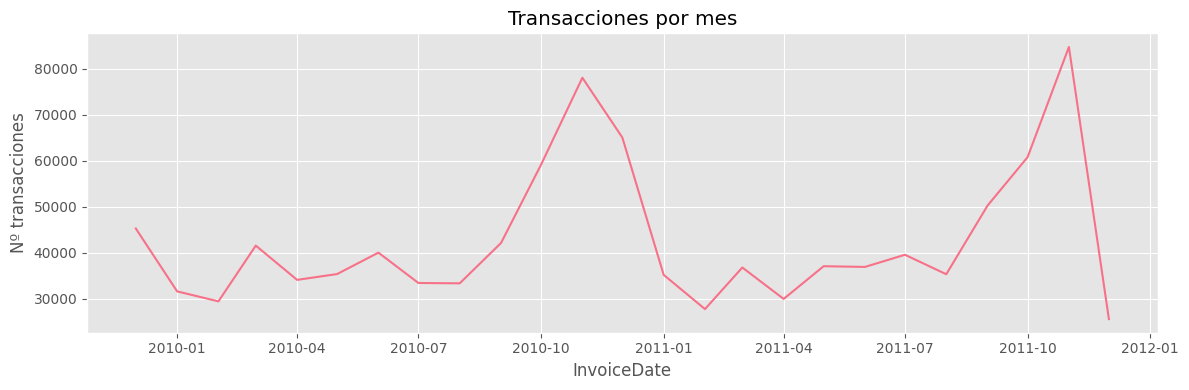

,n_transacciones
InvoiceDate,
2011-01-01,35147
2011-02-01,27707
2011-03-01,36748
2011-04-01,29916
2011-05-01,37030
2011-06-01,36874
2011-07-01,39518
2011-08-01,35284
2011-09-01,50226


In [46]:
# ============================================
# 9.5 Transacciones por mes
# ============================================

if 'InvoiceDate' in df.columns:
    df_ts = df.dropna(subset=['InvoiceDate']).copy()
    df_ts['InvoiceDate'] = pd.to_datetime(df_ts['InvoiceDate'], errors='coerce')
    df_ts = df_ts.dropna(subset=['InvoiceDate'])

    trans_month = (
        df_ts.set_index('InvoiceDate')
        .resample('MS')
        .size()
    )

    plt.figure(figsize=(12, 4))
    plt.plot(trans_month.index, trans_month.values)
    plt.title("Transacciones por mes")
    plt.xlabel("InvoiceDate")
    plt.ylabel("Nº transacciones")
    plt.tight_layout()
    plt.show()

    display(trans_month.to_frame("n_transacciones").tail(12))
else:
    print("No existe la columna 'InvoiceDate'.")

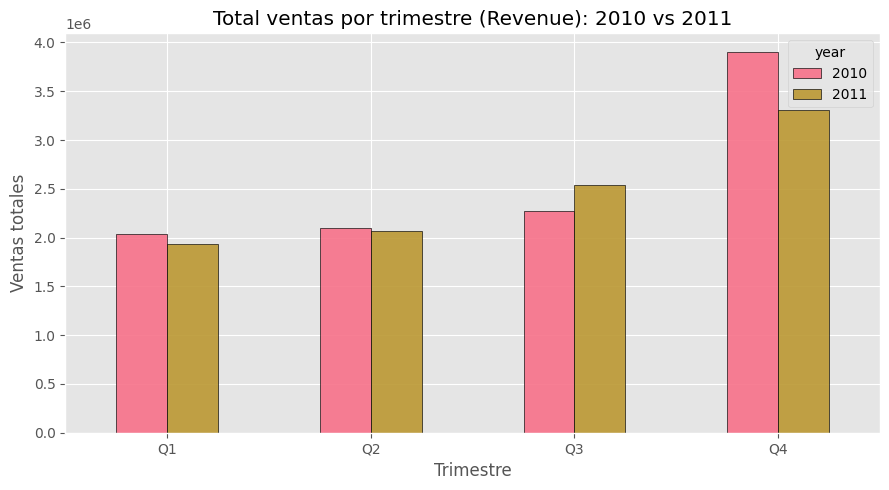

year,2010,2011
quarter,,
Q1,2039991.94,1932635.81
Q2,2093657.99,2070084.54
Q3,2272320.86,2536949.74
Q4,3898355.18,3303286.31


In [47]:
# ============================================
# 9.7 Revenue trimestral: 2010 vs 2011
# ============================================

if all(c in df.columns for c in ['InvoiceDate', 'Quantity', 'Price']):
    v = df.dropna(subset=['InvoiceDate']).copy()
    v['InvoiceDate'] = pd.to_datetime(v['InvoiceDate'], errors='coerce')
    v = v.dropna(subset=['InvoiceDate'])

    # Solo ventas positivas para comparar revenue comercial real
    v = v[(v['Quantity'] > 0) & (v['Price'] > 0)].copy()
    v['Revenue'] = v['Quantity'] * v['Price']
    v['year'] = v['InvoiceDate'].dt.year
    v['quarter'] = 'Q' + v['InvoiceDate'].dt.quarter.astype(str)

    v = v[v['year'].isin([2010, 2011])]

    tot = (
        v.groupby(['quarter', 'year'])['Revenue']
        .sum()
        .unstack(fill_value=0)
        .reindex(index=['Q1', 'Q2', 'Q3', 'Q4'])
        .fillna(0)
    )

    ax = tot.plot(kind='bar', figsize=(9, 5), edgecolor='black', alpha=0.9)
    ax.set_title("Total ventas por trimestre (Revenue): 2010 vs 2011")
    ax.set_xlabel("Trimestre")
    ax.set_ylabel("Ventas totales")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    display(tot.round(2))
else:
    print("Faltan columnas necesarias: 'InvoiceDate', 'Quantity' y/o 'Price'.")

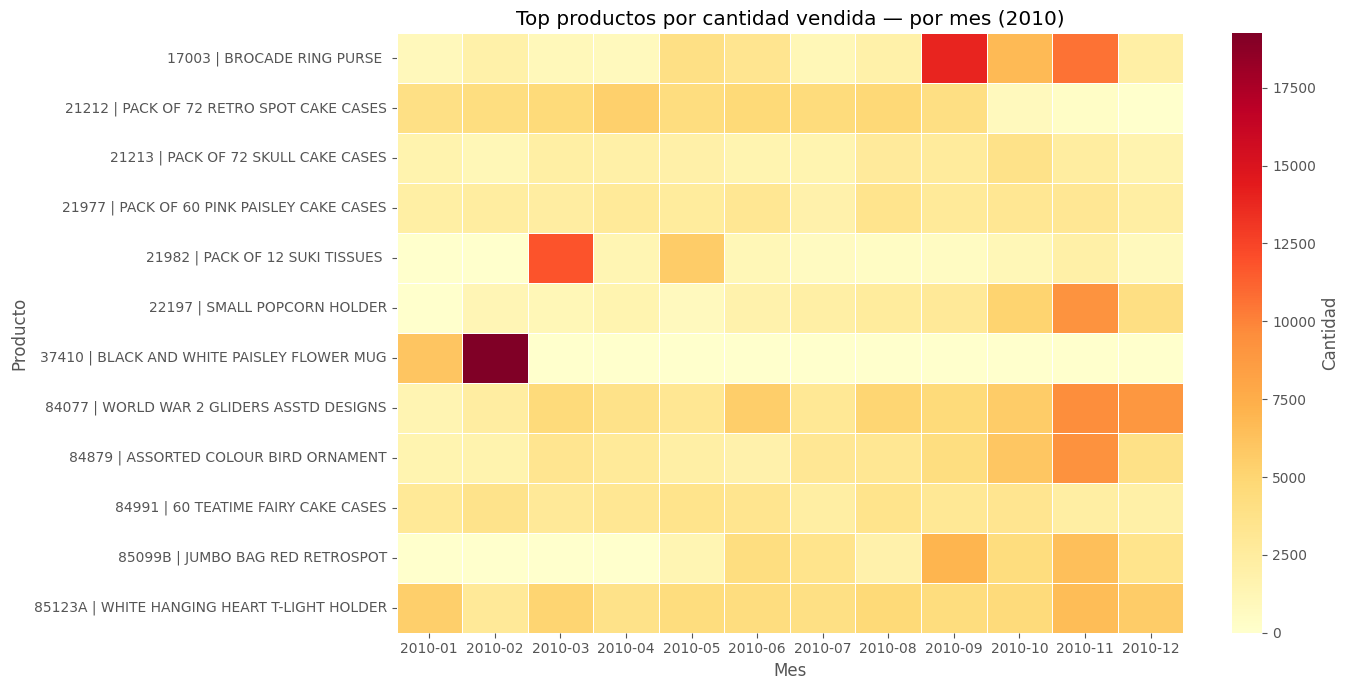

In [48]:
# ============================================
# 9.8 Heatmap top productos por mes
# ============================================

import seaborn as sns

needed_cols = ['InvoiceDate', 'StockCode', 'Description', 'Quantity']
if all(c in df.columns for c in needed_cols):
    hm = df.copy()
    hm['InvoiceDate'] = pd.to_datetime(hm['InvoiceDate'], errors='coerce')
    hm = hm.dropna(subset=['InvoiceDate', 'Description'])
    hm = hm[hm['Quantity'] > 0].copy()

    hm['year'] = hm['InvoiceDate'].dt.year
    hm['month'] = hm['InvoiceDate'].dt.to_period('M').astype(str)

    # Puedes fijar 2010 para que quede más limpio visualmente
    hm_2010 = hm[hm['year'] == 2010].copy()

    top_n = 12
    top_products_hm = (
        hm_2010.groupby(['StockCode', 'Description'])['Quantity']
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    top_keys = set(zip(top_products_hm['StockCode'], top_products_hm['Description']))

    hm_2010['product_key'] = list(zip(hm_2010['StockCode'], hm_2010['Description']))
    hm_2010 = hm_2010[hm_2010['product_key'].isin(top_keys)].copy()
    hm_2010['product_label'] = hm_2010['StockCode'].astype(str) + " | " + hm_2010['Description']

    pivot_m = hm_2010.pivot_table(
        index='product_label',
        columns='month',
        values='Quantity',
        aggfunc='sum',
        fill_value=0
    )

    plt.figure(figsize=(14, 7))
    sns.heatmap(pivot_m, cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Cantidad'})
    plt.title("Top productos por cantidad vendida — por mes (2010)")
    plt.xlabel("Mes")
    plt.ylabel("Producto")
    plt.tight_layout()
    plt.show()
else:
    print("Faltan columnas necesarias para el heatmap.")

## 10. Conclusiones

## Conclusiones del proyecto

En este proyecto he construido un modelo capaz de predecir la recompra de clientes a partir de su comportamiento histórico.

### Principales conclusiones

- El modelo alcanza un rendimiento sólido, con un AUC cercano a 0.80
- Las variables RFM son los principales drivers de la recompra
- La optimización mejora el rendimiento del modelo
- La explicabilidad permite entender las decisiones del modelo
- La segmentación final permite traducir los resultados a acciones de negocio

### Reflexión final

El proyecto demuestra que, con datos históricos bien tratados y variables adecuadas, es posible anticipar el comportamiento del cliente y tomar decisiones más eficientes.